In [1]:
import datetime, time
import simpy

import shapely.geometry
import pandas as pd

import openclsim.core as core
import openclsim.model as model
import openclsim.plot as plot

In [2]:
# setup environment
simulation_start = 0
my_env = simpy.Environment(initial_time=simulation_start)

In [3]:
# create a Site object based on desired mixin classes
Site = type(
    "Site",
    (
        core.Identifiable,
        core.Log,
        core.Locatable,
        core.HasContainer,
        core.HasResource,
        core.HasSoilTSHD,
    ),
    {},
)

# create a TransportProcessingResource object based on desired mixin classes
TransportProcessingResource = type(
    "TransportProcessingResource",
    (
        core.IsTSHD,
        core.ContainerDependentMovable,
        core.Processor,
        core.HasResource,
        core.LoadingFunction,
        core.UnloadingFunction,
        core.Identifiable,
        core.Log,
    ),
    {},
)

In [4]:
# prepare input data for from_site
location_from_site = shapely.geometry.Point(4.18055556, 52.18664444)
data_from_site = {"env": my_env,
                  "name": "from_site",
                  "geometry": location_from_site,
                  "capacity": 100,
                  "level": 50,
                  "rho_particle": 2600,
                  "rho_water": 1025,
                  "compaction_force": 6,
                  "initial_permeabilty": 0.44,
                  "permeability_cutting_teeth": 4.5e-04,
                  "dilatancy": 0.000025,
                  "viscosity_water": 0.000001,
                  "water_depth": 16.5,
                  "gravitatinal_acceleration": 9.81,
                  "mass_flux_coefficient": 0.1,
                  "initial_porosity": 0.44,
                  "porosity_cutting_teeth": 0.44,
                 }
# instantiate from_site 
from_site = Site(**data_from_site)

# prepare input data for to_site
location_to_site = shapely.geometry.Point(4.25222222, 52.11428333)
data_to_site = {"env": my_env,
                "name": "to_site",
                "geometry": location_to_site,
                "capacity": 50,
                "level": 0,
                "rho_particle": 2600,
                "rho_water": 1025,
                "compaction_force": 6,
                "initial_permeabilty": 0.44,
                "permeability_cutting_teeth": 4.5e-04,
                "dilatancy": 0.000025,
                "viscosity_water": 0.000001,
                "water_depth": 16.5,
                "gravitatinal_acceleration": 9.81,
                "mass_flux_coefficient": 0.1,
                "initial_porosity": 0.44,
                "porosity_cutting_teeth": 0.44,
               }
# instantiate to_site 
to_site = Site(**data_to_site)

In [5]:
# prepare input data for vessel_01
data_vessel01 = {"env": my_env,
                 "name": "vessel01",
                 "geometry": location_from_site, 
                 "loading_rate": 0.00001,
                 "unloading_rate": 0.00001,
                 "capacity": 5,
                 "compute_v": lambda x: 10,
                 "width_single_visor": 2.810,
                 "visor_angle": 33,
                 "visor_length": 1.3,
                 "jet_discharge_workingpoint": 1.9,
                 "jet_contraction_coefficient": 0.85,
                 "jet_pipe_diameter": 1.2,
                 "nozzle_diameter": 0.040,
                 "n_nozzles": 26,
                 "rho_particle": 2600,
                 "rho_water": 1025,
                 "compaction_force": 6,
                 "initial_permeabilty": 0.44,
                 "permeability_cutting_teeth": 4.5e-04,
                 "dilatancy": 0.000025,
                 "viscosity_water": 0.000001,
                 "water_depth": 16.5,
                 "gravitatinal_acceleration": 9.81,
                 "mass_flux_coefficient": 0.1,
                 "initial_porosity": 0.44,
                 "porosity_cutting_teeth": 0.44,
               }
# instantiate vessel_01 
vessel01 = TransportProcessingResource(**data_vessel01)

In [6]:
# initialise registry
registry = {}

In [7]:
# create a 'while activity' that contains a pre-packed set of 'sub_processes'
single_run, while_activity  = model.single_run_process(
    name="single_run",
    registry={},
    env=my_env,
    origin=from_site,
    destination=to_site,
    mover=vessel01,
    loader=vessel01,
    unloader=vessel01
)

In [8]:
# initate the simpy processes defined in the 'while activity' and run simpy
model.register_processes([while_activity])
my_env.run()

In [9]:
display(plot.get_log_dataframe(vessel01, [*single_run, while_activity]))

,Activity,Timestamp,ActivityState,container level,geometry
0,single_run sailing empty,1970-01-01 00:00:00.000000,START,0.0,POINT (4.18055556 52.18664444)
1,single_run sailing empty,1970-01-01 00:00:00.000000,STOP,0.0,POINT (4.18055556 52.18664444)
2,single_run loading,1970-01-01 00:00:00.000000,START,0.0,POINT (4.18055556 52.18664444)
3,single_run loading,1970-01-06 18:53:20.000000,STOP,5.0,POINT (4.18055556 52.18664444)
4,single_run sailing filled,1970-01-06 18:53:20.000000,START,5.0,POINT (4.18055556 52.18664444)
...,...,...,...,...,...
75,single_run loading,1970-04-21 03:36:10.842643,STOP,5.0,POINT (4.18055556 52.18664444)
76,single_run sailing filled,1970-04-21 03:36:10.842643,START,5.0,POINT (4.18055556 52.18664444)
77,single_run sailing filled,1970-04-21 03:51:53.667234,STOP,5.0,POINT (4.25222222 52.11428333)
78,single_run unloading,1970-04-21 03:51:53.667234,START,5.0,POINT (4.25222222 52.11428333)


In [10]:
plot.get_gantt_chart([while_activity, vessel01, *single_run])

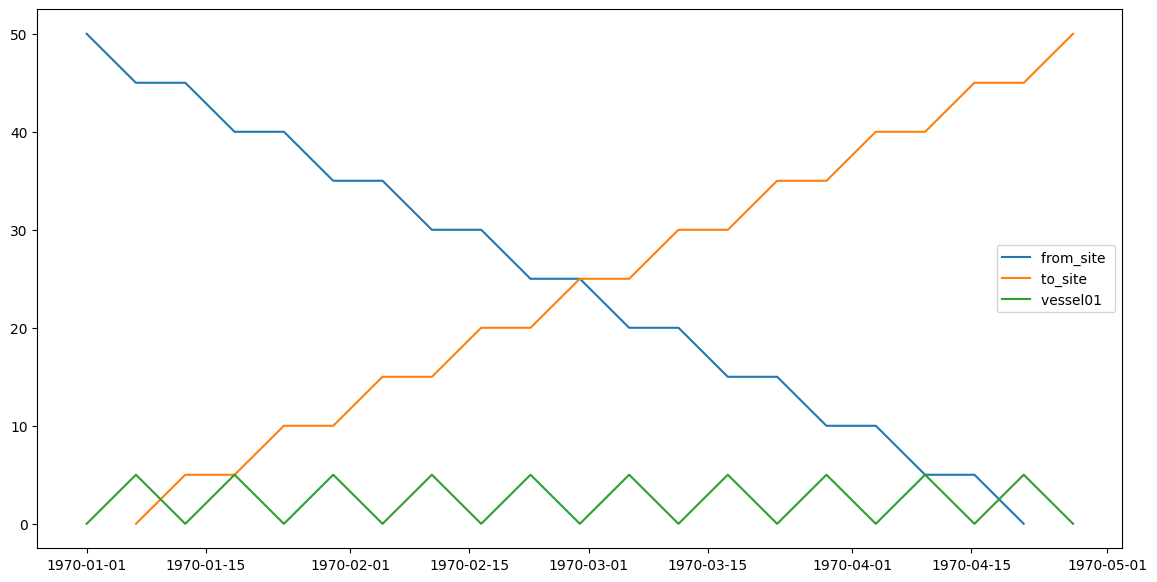

In [11]:
fig = plot.get_step_chart([from_site, to_site, vessel01])